# HCP Brain Network — Community Detection & Functional Labelling

This notebook detects communities using **five algorithms** and assigns each community a **functional brain network label**.

| Algorithm | Type | Key property |
|---|---|---|
| **Greedy Modularity** | Agglomerative | Maximises Q; fast, no parameters |
| **Leiden** | Modularity / CPM | Refinement of Louvain; avoids poorly-connected communities |
| **Infomap** | Information-theoretic | Minimises description length of random walk |
| **Label Propagation** | Semi-random | Near-linear time; stochastic |
| **Spectral Clustering** | Graph Laplacian | Embeds graph in eigenspace before clustering |

**Functional labelling** is done by matching each community's member regions against the known Desikan–Killiany atlas assignments to canonical brain networks (DMN, Sensorimotor, Visual, Frontoparietal, Temporal/Language, Limbic, Salience).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from scipy import stats
from sklearn.cluster import SpectralClustering
from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
import igraph as ig
import leidenalg
import infomap

from enigmatoolbox.datasets import load_sc

np.random.seed(42)
%matplotlib inline
print('All imports successful.')

All imports successful.


---
## Section 0: Data & Functional Network Atlas

We define a **manual anatomical lookup** mapping each of the 68 Desikan–Killiany regions to a canonical functional brain network, based on the established literature.

In [2]:
# ── Load HCP SC ───────────────────────────────────────────────────────────────
sc_ctx, sc_ctx_labels, sc_sctx, sc_sctx_labels = load_sc()
n = sc_ctx.shape[0]
A_bin = (sc_ctx > 0).astype(float)
G_w  = nx.from_numpy_array(sc_ctx)
G_uw = nx.from_numpy_array(A_bin)

# Strip hemisphere prefix for matching
short_labels = [l.replace('L_','').replace('R_','').lower() for l in sc_ctx_labels]
print(f'Loaded {n} cortical regions')
print('Sample labels:', sc_ctx_labels[:6])

Loaded 68 cortical regions
Sample labels: ['L_bankssts' 'L_caudalanteriorcingulate' 'L_caudalmiddlefrontal'
 'L_cuneus' 'L_entorhinal' 'L_fusiform']


In [3]:
# ── Desikan–Killiany → Functional Network Atlas ────────────────────────────────
# Based on: Yeo et al. 2011 (7-network parcellation) and Buckner et al. 2013
# Each entry is a substring of the DK region name (case-insensitive match)

FUNCTIONAL_ATLAS = {
    'Default Mode Network (DMN)': [
        'posteriorcingulate', 'isthmuscingulate', 'precuneus',
        'medialorbitofrontal', 'frontalpole', 'entorhinal',
        'parahippocampal', 'middletemporal', 'inferiortemporal',
        'angularg', 'bankssts',
    ],
    'Sensorimotor': [
        'precentral', 'postcentral', 'paracentral',
        'superiorfrontal',   # supplementary motor area component
        'rostralmiddlefrontal',  # premotor
    ],
    'Visual': [
        'cuneus', 'lingual', 'pericalcarine',
        'lateraloccipital', 'fusiform', 'lingual',
    ],
    'Frontoparietal (Executive)': [
        'caudalmiddlefrontal', 'parsopercularis', 'parsorbitalis',
        'parstriangularis', 'lateralorbitofrontal',
        'superiorparietal', 'inferiorparietal', 'supramarginal',
    ],
    'Temporal / Language': [
        'superiortemporal', 'transversetemporal',
        'temporalpole', 'caudalanteriorcingulate',
    ],
    'Limbic': [
        'entorhinal', 'parahippocampal', 'temporalpole',
        'caudalanteriorcingulate', 'rostralanteriorcingulate',
    ],
    'Salience / Cingulo-Opercular': [
        'insula', 'rostralanteriorcingulate', 'caudalanteriorcingulate',
    ],
}

NETWORK_COLORS = {
    'Default Mode Network (DMN)': '#E05C5C',
    'Sensorimotor':               '#4A90D9',
    'Visual':                     '#8E44AD',
    'Frontoparietal (Executive)': '#27AE60',
    'Temporal / Language':        '#F39C12',
    'Limbic':                     '#1ABC9C',
    'Salience / Cingulo-Opercular': '#E67E22',
    'Unassigned':                 '#BDC3C7',
}

def assign_known_network(region_short):
    """Return best-matching functional network for a DK region."""
    r = region_short.lower()
    matches = {net: sum(k in r for k in keywords)
               for net, keywords in FUNCTIONAL_ATLAS.items()}
    best_net, best_score = max(matches.items(), key=lambda x: x[1])
    return best_net if best_score > 0 else 'Unassigned'

known_networks = [assign_known_network(s) for s in short_labels]
known_net_series = pd.Series(known_networks, index=sc_ctx_labels)

print('Known network assignment counts:')
print(known_net_series.value_counts().to_string())

Known network assignment counts:
Default Mode Network (DMN)      20
Frontoparietal (Executive)      16
Visual                          10
Sensorimotor                    10
Temporal / Language              8
Limbic                           2
Salience / Cingulo-Opercular     2


---
## Section 1: Community Detection — Five Algorithms

In [4]:
# ── 1. Greedy Modularity (NetworkX) ───────────────────────────────────────────
# Bottom-up agglomeration maximising Newman–Girvan modularity Q
communities_gm = list(nx.community.greedy_modularity_communities(G_uw))
labels_gm = np.zeros(n, dtype=int)
for cid, comm in enumerate(communities_gm):
    for node in comm:
        labels_gm[node] = cid

Q_gm = nx.community.modularity(G_uw, communities_gm)
print(f'Greedy Modularity: {len(communities_gm)} communities, Q = {Q_gm:.4f}')

Greedy Modularity: 3 communities, Q = 0.2641


In [5]:
# ── 2. Leiden Algorithm (igraph + leidenalg) ──────────────────────────────────
# Refinement over Louvain — guarantees well-connected communities
# Build igraph from weighted adjacency
edges = [(i, j) for i in range(n) for j in range(i+1, n) if sc_ctx[i, j] > 0]
weights = [sc_ctx[i, j] for i, j in edges]
G_ig = ig.Graph(n=n, edges=edges)
G_ig.es['weight'] = weights

partition_leiden = leidenalg.find_partition(
    G_ig, leidenalg.ModularityVertexPartition, weights='weight', seed=42
)
labels_leiden = np.array(partition_leiden.membership)
Q_leiden = partition_leiden.modularity
print(f'Leiden:            {len(set(labels_leiden))} communities, Q = {Q_leiden:.4f}')

Leiden:            3 communities, Q = 0.2647


In [6]:
# ── 3. Infomap ────────────────────────────────────────────────────────────────
# Information-theoretic: minimises description length of a random walk
# Finds hierarchical community structure
im = infomap.Infomap('--two-level --seed 42 --silent')
for i, j in G_w.edges():
    w = G_w[i][j]['weight']
    im.add_link(i, j, w)
im.run()

labels_im = np.zeros(n, dtype=int)
for node in im.nodes:
    labels_im[node.node_id] = node.module_id - 1

n_comm_im = len(set(labels_im))
communities_im = [set(np.where(labels_im == c)[0]) for c in range(n_comm_im)]
Q_im = nx.community.modularity(G_uw, communities_im)
print(f'Infomap:           {n_comm_im} communities, Q = {Q_im:.4f}')

Infomap:           1 communities, Q = 0.0000


In [7]:
# ── 4. Label Propagation (NetworkX) ──────────────────────────────────────────
# Near-linear time; stochastic — run 10x and take most common assignment per node
all_lp = []
for seed in range(10):
    np.random.seed(seed)
    comms_lp = list(nx.community.label_propagation_communities(G_uw))
    lab = np.zeros(n, dtype=int)
    for cid, comm in enumerate(comms_lp):
        for node in comm:
            lab[node] = cid
    all_lp.append(lab)

# Consensus: majority vote across runs using mode
labels_lp = stats.mode(np.vstack(all_lp), axis=0).mode.flatten()
# Re-index to 0-based consecutive integers
_, labels_lp = np.unique(labels_lp, return_inverse=True)
communities_lp = [set(np.where(labels_lp == c)[0]) for c in np.unique(labels_lp)]
Q_lp = nx.community.modularity(G_uw, communities_lp)
print(f'Label Propagation: {len(communities_lp)} communities, Q = {Q_lp:.4f}')

Label Propagation: 1 communities, Q = 0.0000


In [8]:
# ── 5. Spectral Clustering ────────────────────────────────────────────────────
# Uses eigenvectors of the normalised Laplacian as node embeddings,
# then applies k-means. We choose k = number of Leiden communities for fair comparison.
k_spectral = len(set(labels_leiden))
sc_model = SpectralClustering(
    n_clusters=k_spectral, affinity='precomputed',
    random_state=42, n_init=20
)
labels_spectral = sc_model.fit_predict(sc_ctx)
communities_spectral = [set(np.where(labels_spectral == c)[0]) for c in range(k_spectral)]
Q_spectral = nx.community.modularity(G_uw, communities_spectral)
print(f'Spectral (k={k_spectral}):      {k_spectral} communities, Q = {Q_spectral:.4f}')

Spectral (k=3):      3 communities, Q = 0.2614


In [9]:
# ── Summary comparison table ───────────────────────────────────────────────────
all_labels = {
    'Greedy Modularity': labels_gm,
    'Leiden':            labels_leiden,
    'Infomap':           labels_im,
    'Label Propagation': labels_lp,
    'Spectral':          labels_spectral,
}
all_Q = {
    'Greedy Modularity': Q_gm,
    'Leiden':            Q_leiden,
    'Infomap':           Q_im,
    'Label Propagation': Q_lp,
    'Spectral':          Q_spectral,
}

summary_rows = []
for name, labs in all_labels.items():
    sizes = [int((labs == c).sum()) for c in np.unique(labs)]
    summary_rows.append({
        'Algorithm':     name,
        'N Communities': len(np.unique(labs)),
        'Modularity Q':  round(all_Q[name], 4),
        'Min size':      min(sizes),
        'Max size':      max(sizes),
        'Mean size':     round(np.mean(sizes), 1),
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

# NMI between all pairs
print('\nNormalized Mutual Information between algorithm pairs:')
alg_names = list(all_labels.keys())
nmi_matrix = np.zeros((len(alg_names), len(alg_names)))
for i, n1 in enumerate(alg_names):
    for j, n2 in enumerate(alg_names):
        nmi_matrix[i, j] = normalized_mutual_info_score(all_labels[n1], all_labels[n2])
nmi_df = pd.DataFrame(nmi_matrix, index=alg_names, columns=alg_names)
print(nmi_df.round(3).to_string())

        Algorithm  N Communities  Modularity Q  Min size  Max size  Mean size
Greedy Modularity              3        0.2641        15        27       22.7
           Leiden              3        0.2647        21        25       22.7
          Infomap              1        0.0000        68        68       68.0
Label Propagation              1        0.0000        68        68       68.0
         Spectral              3        0.2614        20        25       22.7

Normalized Mutual Information between algorithm pairs:
                   Greedy Modularity  Leiden  Infomap  Label Propagation  Spectral
Greedy Modularity              1.000   0.673      0.0                0.0     0.600
Leiden                         0.673   1.000      0.0                0.0     0.852
Infomap                        0.000   0.000      1.0                1.0     0.000
Label Propagation              0.000   0.000      1.0                1.0     0.000
Spectral                       0.600   0.852      0.0        

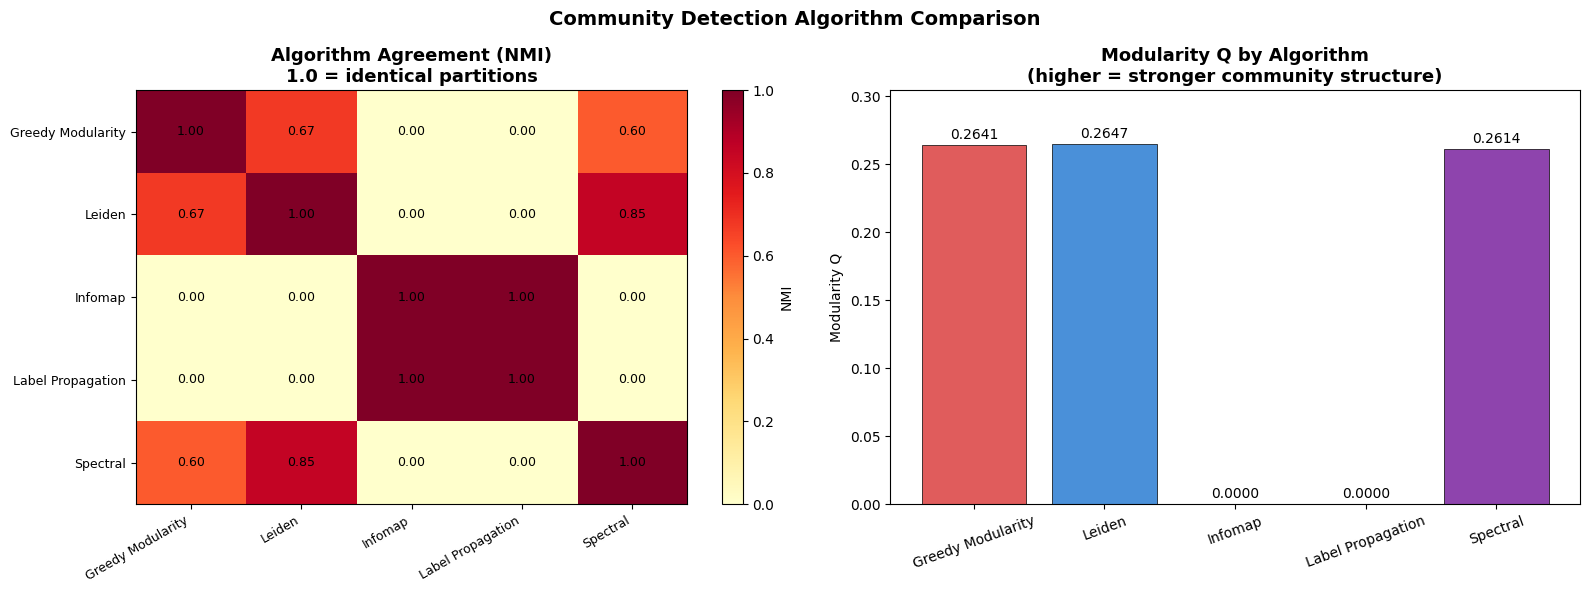

In [10]:
# ── Visualise: NMI heatmap + modularity bar ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# NMI heatmap
im = axes[0].imshow(nmi_matrix, cmap='YlOrRd', vmin=0, vmax=1, aspect='auto')
axes[0].set_xticks(range(len(alg_names)))
axes[0].set_yticks(range(len(alg_names)))
axes[0].set_xticklabels(alg_names, rotation=30, ha='right', fontsize=9)
axes[0].set_yticklabels(alg_names, fontsize=9)
for i in range(len(alg_names)):
    for j in range(len(alg_names)):
        axes[0].text(j, i, f'{nmi_matrix[i,j]:.2f}', ha='center', va='center', fontsize=9)
plt.colorbar(im, ax=axes[0], label='NMI')
axes[0].set_title('Algorithm Agreement (NMI)\n1.0 = identical partitions', fontsize=13, fontweight='bold')

# Modularity bar chart
colors_bar = ['#E05C5C','#4A90D9','#27AE60','#F39C12','#8E44AD']
bars = axes[1].bar(alg_names, [all_Q[a] for a in alg_names],
                   color=colors_bar, edgecolor='k', linewidth=0.5)
axes[1].bar_label(bars, fmt='%.4f', fontsize=10, padding=2)
axes[1].set_title('Modularity Q by Algorithm\n(higher = stronger community structure)',
                  fontsize=13, fontweight='bold')
axes[1].set_ylabel('Modularity Q')
axes[1].set_ylim(0, max(all_Q.values()) * 1.15)
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Community Detection Algorithm Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hcp_community_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 2: Functional Labelling

Each detected community is labelled by finding the **dominant functional network** among its member regions.

We use the **Leiden** partition (highest Q and theoretically strongest) as the primary partition, then repeat for all algorithms.

In [11]:
# ── Functional labelling helper ────────────────────────────────────────────────
def label_communities(labels_arr, method_name):
    """Assign functional label to each community by majority vote."""
    records = []
    for cid in np.unique(labels_arr):
        members_idx  = np.where(labels_arr == cid)[0]
        members_name = sc_ctx_labels[members_idx]
        # Count known network assignments among members
        net_counts = pd.Series([known_networks[i] for i in members_idx]).value_counts()
        top_network = net_counts.index[0]
        top_count   = net_counts.iloc[0]
        purity      = top_count / len(members_idx)
        # Average centrality measures
        strength_arr = sc_ctx.sum(axis=1)
        btw_arr = np.array(list(nx.betweenness_centrality(
            nx.from_numpy_array((sc_ctx > 0).astype(float)),
            normalized=True
        ).values()))
        records.append({
            'Method':           method_name,
            'Community ID':     cid,
            'Size':             len(members_idx),
            'Functional Label': top_network,
            'Purity':           round(purity, 3),
            'Avg Strength':     round(strength_arr[members_idx].mean(), 3),
            'Avg Betweenness':  round(btw_arr[members_idx].mean(), 5),
            'Members':          list(members_name),
        })
    return pd.DataFrame(records)

# Pre-compute betweenness once
btw_arr = np.array(list(nx.betweenness_centrality(
    G_uw, normalized=True
).values()))
strength_arr = sc_ctx.sum(axis=1)

def label_communities(labels_arr, method_name):
    records = []
    for cid in np.unique(labels_arr):
        members_idx  = np.where(labels_arr == cid)[0]
        members_name = sc_ctx_labels[members_idx]
        net_counts   = pd.Series([known_networks[i] for i in members_idx]).value_counts()
        top_network  = net_counts.index[0]
        purity       = net_counts.iloc[0] / len(members_idx)
        records.append({
            'Method'          : method_name,
            'Community ID'    : cid,
            'Size'            : len(members_idx),
            'Functional Label': top_network,
            'Purity'          : round(purity, 3),
            'Avg Strength'    : round(strength_arr[members_idx].mean(), 3),
            'Avg Betweenness' : round(btw_arr[members_idx].mean(), 5),
            'Members'         : list(members_name),
        })
    return pd.DataFrame(records)

# Label all algorithms
all_labelled = pd.concat([
    label_communities(labs, name)
    for name, labs in all_labels.items()
], ignore_index=True)

# Show Leiden result
leiden_labelled = all_labelled[all_labelled['Method'] == 'Leiden'].copy()
print('Leiden community functional labels:')
print(leiden_labelled[['Community ID','Size','Functional Label','Purity','Avg Strength','Avg Betweenness']].to_string(index=False))

Leiden community functional labels:
 Community ID  Size           Functional Label  Purity  Avg Strength  Avg Betweenness
            0    25 Default Mode Network (DMN)   0.280       149.596          0.01047
            1    22               Sensorimotor   0.364       156.961          0.01034
            2    21 Default Mode Network (DMN)   0.333       149.034          0.01248


In [12]:
# ── Detailed membership table per Leiden community ─────────────────────────────
print('Leiden — Full membership with functional labels:\n')
for _, row in leiden_labelled.iterrows():
    print(f"Community {row['Community ID']} [{row['Functional Label']}] "
          f"(n={row['Size']}, purity={row['Purity']:.0%})")
    for m in row['Members']:
        net = known_networks[list(sc_ctx_labels).index(m)]
        print(f"    {m:<40} → {net}")
    print()

Leiden — Full membership with functional labels:

Community 0 [Default Mode Network (DMN)] (n=25, purity=28%)
    L_bankssts                               → Default Mode Network (DMN)
    L_caudalmiddlefrontal                    → Frontoparietal (Executive)
    L_cuneus                                 → Visual
    L_entorhinal                             → Default Mode Network (DMN)
    L_fusiform                               → Visual
    L_inferiorparietal                       → Frontoparietal (Executive)
    L_inferiortemporal                       → Default Mode Network (DMN)
    L_isthmuscingulate                       → Default Mode Network (DMN)
    L_lateraloccipital                       → Visual
    L_lingual                                → Visual
    L_middletemporal                         → Default Mode Network (DMN)
    L_parahippocampal                        → Default Mode Network (DMN)
    L_parsopercularis                        → Frontoparietal (Executive)
    L_pa

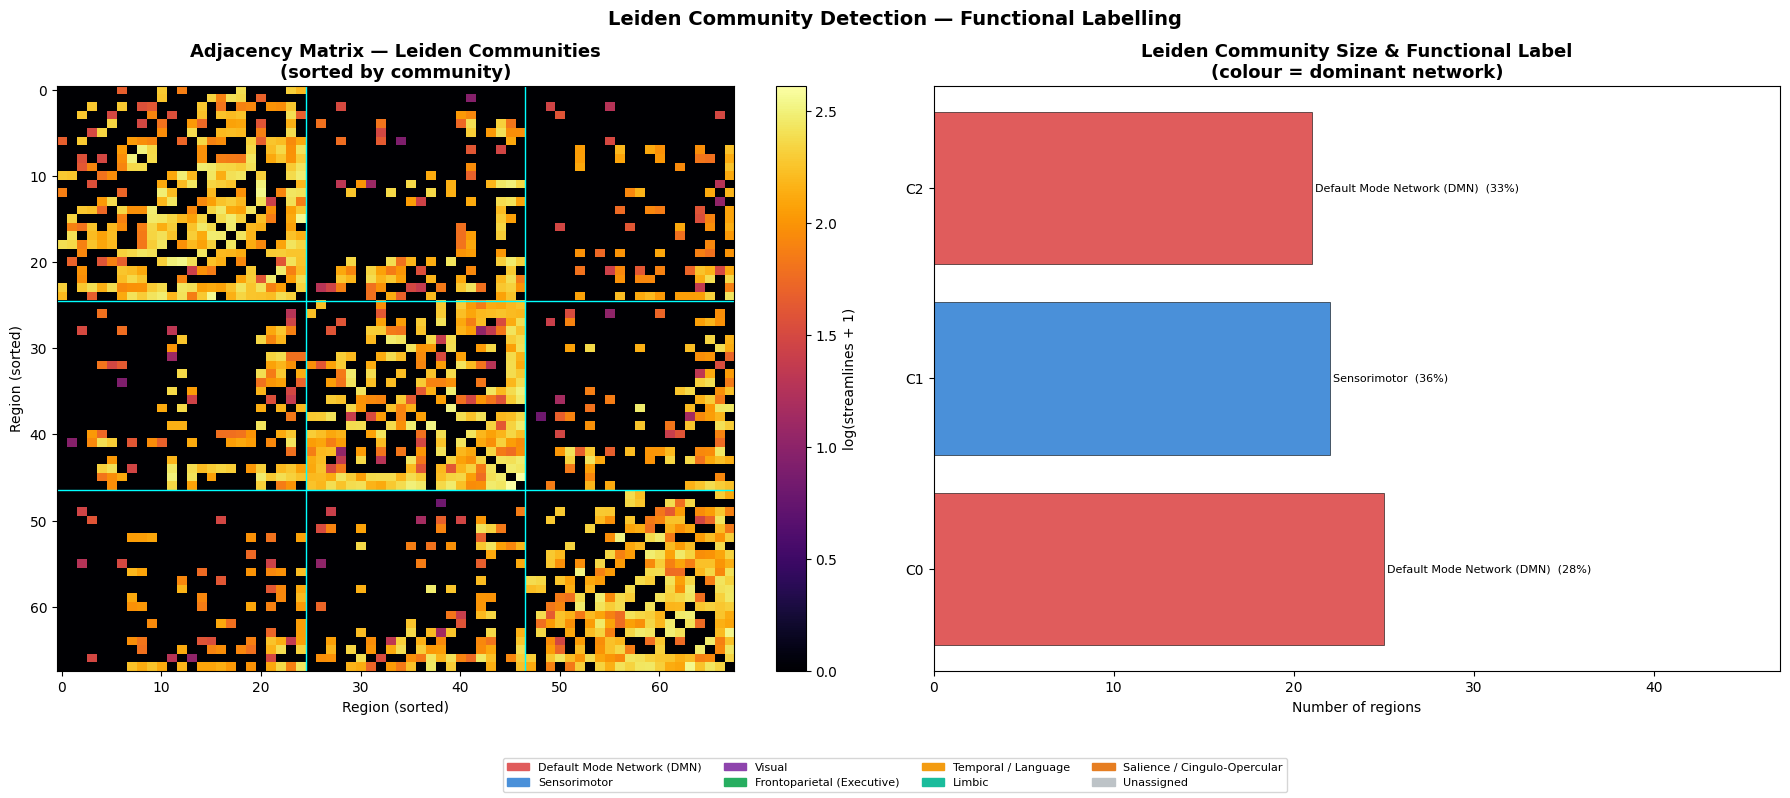

In [13]:
# ── Visualise Leiden communities on adjacency matrix ───────────────────────────
# Sort regions by community then by strength within community
sort_order = np.lexsort((strength_arr, labels_leiden))
sc_sorted  = sc_ctx[np.ix_(sort_order, sort_order)]

# Community boundary positions
_, counts = np.unique(labels_leiden[sort_order], return_counts=True)
boundaries = np.cumsum(counts)[:-1] - 0.5

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Adjacency matrix with community blocks
im = axes[0].imshow(np.log1p(sc_sorted), cmap='inferno', aspect='auto')
for b in boundaries:
    axes[0].axhline(b, color='cyan', linewidth=1.0)
    axes[0].axvline(b, color='cyan', linewidth=1.0)
plt.colorbar(im, ax=axes[0], label='log(streamlines + 1)')
axes[0].set_title('Adjacency Matrix — Leiden Communities\n(sorted by community)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Region (sorted)')
axes[0].set_ylabel('Region (sorted)')

# Community size & functional label bar chart
fn_labels  = leiden_labelled['Functional Label'].tolist()
fn_colors  = [NETWORK_COLORS.get(l, '#BDC3C7') for l in fn_labels]
sizes      = leiden_labelled['Size'].tolist()
purities   = leiden_labelled['Purity'].tolist()
comm_ids   = leiden_labelled['Community ID'].tolist()

bars = axes[1].barh([f'C{i}' for i in comm_ids], sizes, color=fn_colors, edgecolor='k', linewidth=0.4)
for bar, purity, label in zip(bars, purities, fn_labels):
    axes[1].text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
                 f'{label}  ({purity:.0%})', va='center', fontsize=8)
axes[1].set_xlabel('Number of regions')
axes[1].set_title('Leiden Community Size & Functional Label\n(colour = dominant network)', fontsize=13, fontweight='bold')
axes[1].set_xlim(0, max(sizes) + 22)

# Network legend
handles = [mpatches.Patch(color=c, label=n) for n, c in NETWORK_COLORS.items()]
fig.legend(handles=handles, loc='lower center', ncol=4, fontsize=8, frameon=True)

plt.suptitle('Leiden Community Detection — Functional Labelling', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig('hcp_leiden_communities.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Section 3: Cross-Algorithm Functional Label Consistency

Do all five algorithms agree on which regions belong to which functional network?

In [14]:
# ── Per-region: assigned functional label by each algorithm ───────────────────
region_label_df = pd.DataFrame({'Region': sc_ctx_labels, 'Known Network': known_networks})

for name, labs in all_labels.items():
    # Map each node to the functional label of its community
    labelled = label_communities(labs, name)
    node_to_funclabel = {}
    for _, row in labelled.iterrows():
        for member in row['Members']:
            node_to_funclabel[member] = row['Functional Label']
    region_label_df[name] = [node_to_funclabel.get(r, 'Unassigned') for r in sc_ctx_labels]

# Consensus: majority vote across algorithms
algo_cols = list(all_labels.keys())
region_label_df['Consensus'] = region_label_df[algo_cols].apply(
    lambda row: row.value_counts().index[0], axis=1
)
region_label_df['Agreement'] = region_label_df[algo_cols].apply(
    lambda row: row.value_counts().iloc[0] / len(algo_cols), axis=1
)

print('Per-region consensus functional labels (sorted by agreement):')
print(region_label_df[['Region','Known Network','Consensus','Agreement']]
      .sort_values('Agreement')
      .to_string(index=False))

Per-region consensus functional labels (sorted by agreement):
                    Region                Known Network                  Consensus  Agreement
    L_lateralorbitofrontal   Frontoparietal (Executive)               Sensorimotor        0.4
    L_rostralmiddlefrontal                 Sensorimotor               Sensorimotor        0.4
    R_rostralmiddlefrontal                 Sensorimotor               Sensorimotor        0.4
              R_precentral                 Sensorimotor               Sensorimotor        0.4
         R_parsopercularis   Frontoparietal (Executive)               Sensorimotor        0.4
             R_postcentral                 Sensorimotor               Sensorimotor        0.4
    R_lateralorbitofrontal   Frontoparietal (Executive)               Sensorimotor        0.4
     R_caudalmiddlefrontal   Frontoparietal (Executive)               Sensorimotor        0.4
      L_posteriorcingulate   Default Mode Network (DMN) Default Mode Network (DMN)        0.

/tmp/ipykernel_29291/1126547375.py:6: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  heat_data = region_label_df[algo_cols].applymap(
/tmp/ipykernel_29291/1126547375.py:15: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(all_networks))


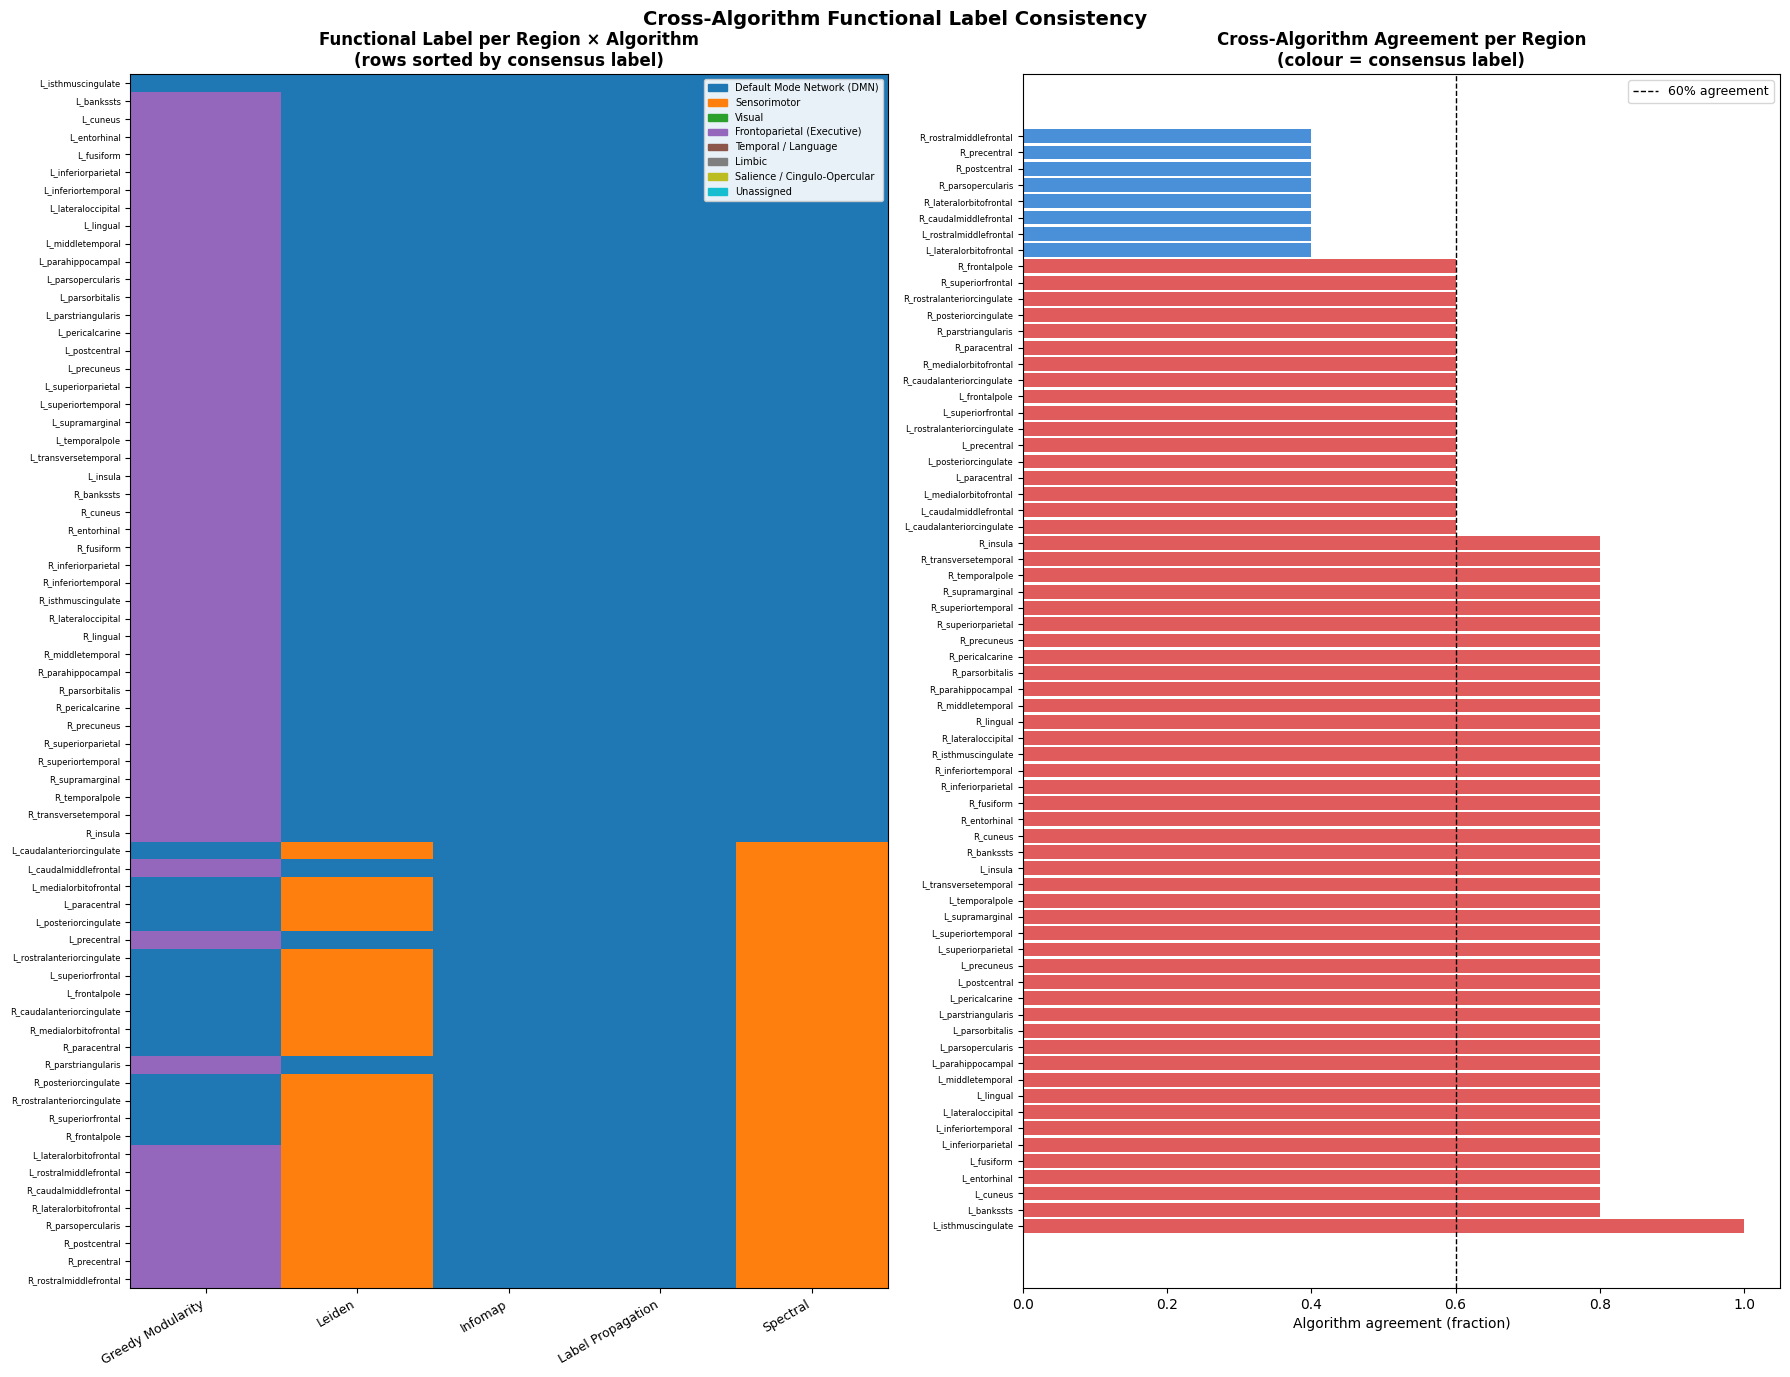


Regions with <60% cross-algorithm agreement (8):
                Region              Known Network    Consensus  Agreement
L_lateralorbitofrontal Frontoparietal (Executive) Sensorimotor        0.4
L_rostralmiddlefrontal               Sensorimotor Sensorimotor        0.4
 R_caudalmiddlefrontal Frontoparietal (Executive) Sensorimotor        0.4
R_lateralorbitofrontal Frontoparietal (Executive) Sensorimotor        0.4
     R_parsopercularis Frontoparietal (Executive) Sensorimotor        0.4
         R_postcentral               Sensorimotor Sensorimotor        0.4
          R_precentral               Sensorimotor Sensorimotor        0.4
R_rostralmiddlefrontal               Sensorimotor Sensorimotor        0.4


In [15]:
# ── Agreement heatmap: region × algorithm ─────────────────────────────────────
# Encode each functional label as an integer for colour mapping
all_networks = list(NETWORK_COLORS.keys())
net_to_int   = {net: i for i, net in enumerate(all_networks)}

heat_data = region_label_df[algo_cols].applymap(
    lambda x: net_to_int.get(x, len(all_networks) - 1)
).values

# Sort rows by consensus label then agreement
sort_idx = region_label_df.sort_values(['Consensus', 'Agreement'], ascending=[True, False]).index

fig, axes = plt.subplots(1, 2, figsize=(18, 14))

cmap = plt.cm.get_cmap('tab10', len(all_networks))
im = axes[0].imshow(heat_data[sort_idx], cmap=cmap, aspect='auto',
                    vmin=0, vmax=len(all_networks) - 1)
axes[0].set_xticks(range(len(algo_cols)))
axes[0].set_xticklabels(algo_cols, rotation=30, ha='right', fontsize=9)
axes[0].set_yticks(range(n))
axes[0].set_yticklabels(region_label_df.loc[sort_idx, 'Region'], fontsize=6)
axes[0].set_title('Functional Label per Region × Algorithm\n(rows sorted by consensus label)',
                  fontsize=12, fontweight='bold')
handles = [mpatches.Patch(color=cmap(i), label=net) for i, net in enumerate(all_networks)]
axes[0].legend(handles=handles, loc='upper right', fontsize=7, framealpha=0.9)

# Agreement score per region
agreement_sorted = region_label_df.loc[sort_idx, 'Agreement']
consensus_sorted = region_label_df.loc[sort_idx, 'Consensus']
bar_colors = [NETWORK_COLORS.get(c, '#BDC3C7') for c in consensus_sorted]

axes[1].barh(range(n), agreement_sorted.values, color=bar_colors,
             edgecolor='none', height=0.85)
axes[1].set_yticks(range(n))
axes[1].set_yticklabels(region_label_df.loc[sort_idx, 'Region'], fontsize=6)
axes[1].axvline(0.6, color='k', linewidth=1, linestyle='--', label='60% agreement')
axes[1].set_xlabel('Algorithm agreement (fraction)')
axes[1].set_title('Cross-Algorithm Agreement per Region\n(colour = consensus label)',
                  fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)

plt.suptitle('Cross-Algorithm Functional Label Consistency', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hcp_cross_algorithm_labels.png', dpi=150, bbox_inches='tight')
plt.show()

# Regions with low agreement
low_agree = region_label_df[region_label_df['Agreement'] < 0.6]
print(f'\nRegions with <60% cross-algorithm agreement ({len(low_agree)}):')
print(low_agree[['Region','Known Network','Consensus','Agreement']].to_string(index=False))

---
## Section 4: Community-Level Network Properties

For the Leiden communities, compute internal cohesion (within-community density) and external coupling (between-community edge weight) to characterise each community structurally.

In [16]:
# ── Within- and between-community connectivity ─────────────────────────────────
unique_comms = np.unique(labels_leiden)
n_comm = len(unique_comms)

within_density  = np.zeros(n_comm)
within_strength = np.zeros(n_comm)
between_strength = np.zeros((n_comm, n_comm))

for i, ci in enumerate(unique_comms):
    mi = np.where(labels_leiden == ci)[0]
    sub_w = sc_ctx[np.ix_(mi, mi)]
    sub_b = (sub_w > 0).astype(float)
    n_i   = len(mi)
    possible = n_i * (n_i - 1) / 2
    within_density[i]  = sub_b.sum() / 2 / possible if possible > 0 else 0
    within_strength[i] = sub_w.sum() / 2

    for j, cj in enumerate(unique_comms):
        if j > i:
            mj = np.where(labels_leiden == cj)[0]
            bw = sc_ctx[np.ix_(mi, mj)].sum()
            between_strength[i, j] = bw
            between_strength[j, i] = bw

# Participation coefficient: how spread are each node's connections across communities?
def participation_coefficient(A, labels):
    n_nodes = A.shape[0]
    pc = np.zeros(n_nodes)
    for i in range(n_nodes):
        ki = A[i].sum()
        if ki == 0:
            continue
        pc[i] = 1 - sum(
            (A[i][labels == c].sum() / ki) ** 2
            for c in np.unique(labels)
        )
    return pc

pc = participation_coefficient(sc_ctx, labels_leiden)

# Intra-community z-score (how connected is node relative to its community?)
def intra_z_score(A, labels):
    z = np.zeros(A.shape[0])
    for c in np.unique(labels):
        members = np.where(labels == c)[0]
        k_intra = A[np.ix_(members, members)].sum(axis=1)
        if k_intra.std() > 0:
            z[members] = (k_intra - k_intra.mean()) / k_intra.std()
    return z

z_score = intra_z_score(sc_ctx, labels_leiden)

# Cartographic map classification (Guimerà & Amaral 2005)
def cartographic_role(z, pc):
    """Classify into hub/non-hub connector/peripheral roles."""
    roles = []
    for zi, pci in zip(z, pc):
        if zi >= 2.5:   # hub
            if pci < 0.30:   roles.append('Provincial Hub')
            elif pci < 0.75: roles.append('Connector Hub')
            else:             roles.append('Kinless Hub')
        else:           # non-hub
            if pci < 0.05:   roles.append('Ultra-peripheral')
            elif pci < 0.62: roles.append('Peripheral')
            elif pci < 0.80: roles.append('Connector')
            else:             roles.append('Kinless')
    return roles

cartographic_roles = cartographic_role(z_score, pc)

cart_df = pd.DataFrame({
    'Region':    sc_ctx_labels,
    'Community': labels_leiden,
    'Func Label': [known_networks[i] for i in range(n)],
    'z (intra)': z_score.round(3),
    'PC':        pc.round(3),
    'Cart Role': cartographic_roles,
})

print('Cartographic role distribution:')
print(cart_df['Cart Role'].value_counts().to_string())
print()
print(cart_df[cart_df['Cart Role'].str.contains('Hub')][['Region','Func Label','z (intra)','PC','Cart Role']].to_string(index=False))

Cartographic role distribution:
Cart Role
Peripheral          57
Connector            6
Ultra-peripheral     3
Connector Hub        2

           Region   Func Label  z (intra)    PC     Cart Role
L_superiorfrontal Sensorimotor      2.641 0.495 Connector Hub
R_superiorfrontal Sensorimotor      2.870 0.530 Connector Hub


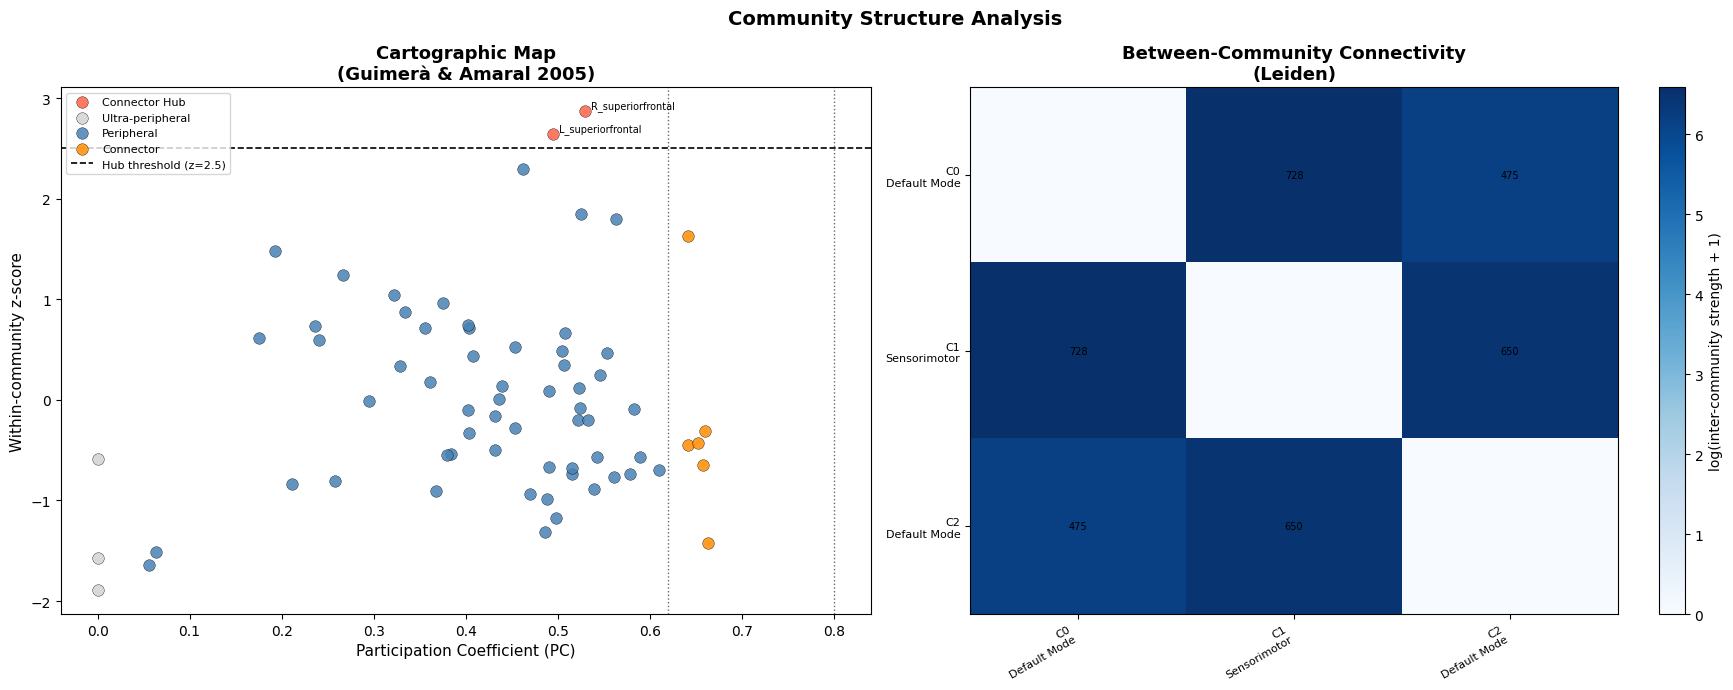

In [17]:
# ── Cartographic map (z vs PC scatter) ───────────────────────────────────────
cart_colors = {
    'Provincial Hub':  'darkred',
    'Connector Hub':   'tomato',
    'Kinless Hub':     'salmon',
    'Ultra-peripheral':'lightgray',
    'Peripheral':      'steelblue',
    'Connector':       'darkorange',
    'Kinless':         'mediumpurple',
}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Cartographic map
for role, color in cart_colors.items():
    sub = cart_df[cart_df['Cart Role'] == role]
    if len(sub) == 0:
        continue
    axes[0].scatter(sub['PC'], sub['z (intra)'], c=color, s=70,
                    label=role, edgecolors='k', linewidths=0.3, alpha=0.85)
for _, row in cart_df[cart_df['Cart Role'].str.contains('Hub')].iterrows():
    axes[0].annotate(row['Region'], (row['PC'], row['z (intra)']),
                     fontsize=7, xytext=(4, 2), textcoords='offset points')

axes[0].axhline(2.5, color='k', linewidth=1.2, linestyle='--', label='Hub threshold (z=2.5)')
axes[0].axvline(0.62, color='k', linewidth=1.0, linestyle=':', alpha=0.6)
axes[0].axvline(0.80, color='k', linewidth=1.0, linestyle=':', alpha=0.6)
axes[0].set_xlabel('Participation Coefficient (PC)', fontsize=11)
axes[0].set_ylabel('Within-community z-score', fontsize=11)
axes[0].set_title('Cartographic Map\n(Guimerà & Amaral 2005)', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=8, loc='upper left')

# Between-community strength matrix
fn_labels_comm = [leiden_labelled[leiden_labelled['Community ID'] == c]['Functional Label'].values[0]
                  for c in unique_comms]
bw_labels = [f'C{c}\n{fn_labels_comm[i][:12]}' for i, c in enumerate(unique_comms)]
im2 = axes[1].imshow(np.log1p(between_strength), cmap='Blues', aspect='auto')
axes[1].set_xticks(range(n_comm))
axes[1].set_yticks(range(n_comm))
axes[1].set_xticklabels(bw_labels, rotation=30, ha='right', fontsize=8)
axes[1].set_yticklabels(bw_labels, fontsize=8)
for i in range(n_comm):
    for j in range(n_comm):
        if i != j:
            axes[1].text(j, i, f'{between_strength[i,j]:.0f}', ha='center',
                         va='center', fontsize=7)
plt.colorbar(im2, ax=axes[1], label='log(inter-community strength + 1)')
axes[1].set_title('Between-Community Connectivity\n(Leiden)', fontsize=13, fontweight='bold')

plt.suptitle('Community Structure Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('hcp_community_structure.png', dpi=150, bbox_inches='tight')
plt.show()

In [18]:
# ── Final summary: community functional profile ───────────────────────────────
final_rows = []
for _, row in leiden_labelled.iterrows():
    cid = row['Community ID']
    members = np.where(labels_leiden == cid)[0]
    hub_count  = sum(1 for i in members if 'Hub' in cart_df.loc[cart_df['Region'] == sc_ctx_labels[i], 'Cart Role'].values[0])
    conn_count = sum(1 for i in members if 'Connector' in cart_df.loc[cart_df['Region'] == sc_ctx_labels[i], 'Cart Role'].values[0])
    final_rows.append({
        'Community'         : f'C{cid}',
        'Functional Label'  : row['Functional Label'],
        'Size'              : row['Size'],
        'Purity'            : f"{row['Purity']:.0%}",
        'Hubs inside'       : hub_count,
        'Connectors inside' : conn_count,
        'Within density'    : round(within_density[cid], 3),
        'Avg Strength'      : row['Avg Strength'],
    })

final_df = pd.DataFrame(final_rows)
print('Final Community Functional Profile (Leiden):')
print(final_df.to_string(index=False))

Final Community Functional Profile (Leiden):
Community           Functional Label  Size Purity  Hubs inside  Connectors inside  Within density  Avg Strength
       C0 Default Mode Network (DMN)    25    28%            0                  2           0.533       149.596
       C1               Sensorimotor    22    36%            2                  3           0.576       156.961
       C2 Default Mode Network (DMN)    21    33%            0                  3           0.595       149.034
